In [2]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import RemoveMessage

In [3]:
load_dotenv()

True

In [4]:
model = ChatGoogleGenerativeAI(model="gemini-3.6-flash")

In [5]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [7]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [8]:
graph = builder.compile(checkpointer=InMemorySaver())

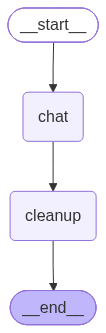

In [9]:
graph

In [10]:
config = {"configurable": {"thread_id": "t1"}}

In [11]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Khan"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='51836408-12b5-4c66-b078-5a49d562e20f'),
  AIMessage(content=[{'type': 'text', 'text': '**LangChain** is an open-source framework designed to help developers build applications powered by Large Language Models (LLMs). \n\nIf an LLM (like GPT-4 or Claude) is the **"brain,"** LangChain is the **"body"**—it connects the brain to external data sources, software tools, databases, and user interfaces.\n\n---\n\n### The Problem LangChain Solves\n\nUsing a raw LLM API (like OpenAI\'s API) is great for simple text generation, but building real-world software with it is hard because:\n1. **LLMs lack private data:** They only know what they were trained on. They can\'t read your company\'s internal PDFs, databases, or live web data by default.\n2. **Vendor Lock-in:** Switching your app from OpenAI to Anthropic or a open-source model like Llama 3 requires rewriting a lot of code.\n3. **No built-i

In [12]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8


In [13]:
for m in graph.get_state(config).values['messages']:
    tpm=type(m).__name__
    if(tpm=="AIMessage"):
            print("-",tpm,":",m.text)
            print('-'*120)
            continue
    print("-", tpm, ":", m.content)
    print('-'*120)

- HumanMessage : What is Langchain
------------------------------------------------------------------------------------------------------------------------
- AIMessage : **LangChain** is an open-source framework designed to help developers build applications powered by Large Language Models (LLMs). 

If an LLM (like GPT-4 or Claude) is the **"brain,"** LangChain is the **"body"**—it connects the brain to external data sources, software tools, databases, and user interfaces.

---

### The Problem LangChain Solves

Using a raw LLM API (like OpenAI's API) is great for simple text generation, but building real-world software with it is hard because:
1. **LLMs lack private data:** They only know what they were trained on. They can't read your company's internal PDFs, databases, or live web data by default.
2. **Vendor Lock-in:** Switching your app from OpenAI to Anthropic or a open-source model like Llama 3 requires rewriting a lot of code.
3. **No built-in memory:** LLM APIs are stateless;